# Исследование данных для предсказания рисков сердечных приступов

## Описание исследования
Мы располагаем данными о пациентах, отсящихся к двум группам: с высоким или низким риском поражения сердца. Нам нужно провести исследовательских анализ данных, предобработать и обучить модель для предсказания к какой группе можно отнести пацаента. Таким образом можно подытожить, что это задача **бинарной классификации**. Данные представлены двумя датасетами: heart_train.csv и heart_test.csv. Первый - тренировочной, второй, соответственно, тестовый и не имеет целевого признака.

В данных есть **признаки:**
- id - уникальный идентификатор пациента.
- Антропометрические параметры (вес, возраст, рост).
- Привычки (курение, качество сна и т.д).
- Давление.
- Наличие хронических заболеваний.
- Биохимия крови.
- Таргет - высокий или низкий риск поражения сердца.

**Ход исследования:**
- Загрузка и обзор данных.
    - Загрузка датасетов.
    - Обзор данных.
- Предобработка данных.
    - Проверка и обработка дубликатов, типов данных.
    - Обработку пропусков будем делать в пайплайне.
- Исследовательский анализ данных.
    - Анализ распределений и статистики.
    - Анализ корреляций и зависимостей.
    - Сделать выводы о том, как подготовить данные для моделей.
- Подготовка данных для моделей.
    - Устранение бесполезных признаков.
    - *feature engineering* при необходимости.
    - Построение пайплайнов.
- Обучение моделей.
    - Обучить несколько моделей и выбрав лучшую.
    - Выбрать лучшие гиперпараметры для модели. 
- Выводы.

#### Цель исследования:
Создать модель, решающую задачу бинарной классификации, успехом будем считать показатель метрики ROC-AUC > 0.6. 

#### 0. Технический блок

Подключение библиотек, объявление констант, перечисление функций.

In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline


In [349]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [350]:
# Функции первичного анализа датасета

def print_header(header: str, symbol: str = '=') -> None:
    """
    Оформленный вывод заголовка для функций

    Args:
        header (str): заголовок
        symbol (str, optional):символ для резделителя. Defaults to '='.
    """
    print("\n" + symbol*50)
    print(header)
    print(symbol*50)
    print()
    
    
def print_info(data: pd.DataFrame) -> None:
    """
    Компонент check_dataframe()

    Args:
        data (pd.DataFrame): датафрейм  для анализа
    """
    print_header(f"ОБЩАЯ ИНФОРМАЦИЯ [Строк: {len(data)}, Колонок: {len(data.columns)}]")
    dtype_report = data.dtypes.reset_index()
    dtype_report.columns = ['Колонка', 'Тип данных']
    dtype_report['Тип данных'] = dtype_report['Тип данных'].astype(str)
    print("Типы данных колонок:")
    print(dtype_report.to_string(index=False))
    print()
    
    
def show_na_rows(data: pd.DataFrame, max_na_rows: int = 50) -> None:
    """
    Компонент check_dataframe()

    Args:
        data (pd.DataFrame): датафрейм для анализа
        max_na_rows (int, optional): максимальное количество отображаемых строк
        с NAN. Defaults to 50.
    """
    print_header("СТРОКИ С ПРОПУЩЕННЫМИ ЗНАЧЕНИЯМИ", "-")
    na_rows = data[data.isnull().any(axis=1)]
    print(f"Всего строк с пропусками: {len(na_rows)}")
    
    if len(na_rows) > max_na_rows:
        print(f"Показано первых {max_na_rows} строк:")
        print(na_rows.head(max_na_rows).to_string(index=True))
    else:
        print(na_rows.to_string(index=True))
    
    
def check_nan(data: pd.DataFrame, show_rows: bool = True) -> None:
    """
    Компонент check_dataframe()

    Args:
        data (pd.DataFrame): датафрейм для анализа.
        show_rows (bool, optional): показывать ли строки с пропущенными 
        значениями при наличии. Defaults to True.
    """
    print_header("ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ")
    na_report = data.isnull().sum().to_frame(name='NAN_count')
    na_report['NAN_%'] = (na_report['NAN_count'] / len(data) * 100).round(2)
    if na_report['NAN_count'].sum() > 0:
        print(na_report[na_report['NAN_count'] > 0])
        if show_rows: 
            show_na_rows(data)
    else:
        print("Пропуски отсутствуют")
    print()
    

def check_duplicates(data: pd.DataFrame, id_column_name) -> None:
    """
    Компонент check_dataframe()

    Args:
        data (pd.DataFrame): датафрейм для анализа.
        id_column_name (_type_): название колонки с id
    """
    print_header("ДУБЛИКАТЫ ID")
    id_dups = data[id_column_name].duplicated().sum()
    if id_dups > 0:
        print(f"Обнаружено дубликатов: {id_dups}")
        duplicated_ids = data[data[id_column_name].duplicated(keep=False)][id_column_name].unique()
        print(f"Примеры дублированных ID: {duplicated_ids[:5]}{'...' if len(duplicated_ids) > 5 else ''}")
    else:
        print("Дубликаты отсутствуют")
    print()
    

def check_unique_values(data: pd.DataFrame) -> None:
    """
    Компонент check_dataframe()

    Args:
        data (pd.DataFrame): датафрейм для анализа.
    """
    print_header("УНИКАЛЬНЫЕ ЗНАЧЕНИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
    cat_cols = data.select_dtypes(exclude='number').columns.tolist()
    
    if not cat_cols:
        print("Категориальные колонки отсутствуют")
        return
        
    for col in cat_cols:
        unique_vals = data[col].dropna().unique()
        print(f"\n● Колонка '{col}':")
        print(f"Уникальных значений: {len(unique_vals)}")
        
        if len(unique_vals) <= 10:
            print(f"Список: {', '.join(map(str, unique_vals))}")
        else:
            sample = ", ".join(map(str, unique_vals[:5]))
            print(f"Примеры: {sample}...")


def check_dataframe(data: pd.DataFrame, 
                    id_column_name: str = 'id',
                    implicit_duplicates_check: bool = True,
                    show_nan_rows: bool = True) -> None:
    """
    Метод проверки(только выводит информацию) датафрейма по основным пунктам:
    - Пропуски во всем датафрейме
    - Явные дубликаты в колонке id
    - Неявные дубликаты в категориальных признаках

    Args:
        data (pd.DataFrame): датафрейм для проверки
        id_column_name (str, optional): имя колонки со значениями id. Defaults to 'id'.
        implicit_duplicates_check (bool, optional): проверять ли на неявные дубликаты. Defaults to True.
        show_nan_rows (bool, optional): показывать ли строки с пропущенными значениями
    """
    print_info(data)
    check_nan(data, show_nan_rows)
    check_duplicates(data, id_column_name)    
    if implicit_duplicates_check:
        check_unique_values(data)


In [379]:
# функции для базовго анализа датасетов

def analyze_continuous_features(data: pd.DataFrame, 
                         figsize: tuple=(15, 8), 
                         top: float=0.82,
                         continuous_features: list[str]=[]):
    """
    Функция для рисования боксплота и гистограммы.

    Args:
        data (pd.DataFrame): датафрейм для работы
        figsize (tuple, optional): размер фигур. Defaults to (15, 8).
        top (float, optional): расстояние между заголовком и графиками. Defaults to 0.92.
        continuous_features (list[str], optional): список столбцов, по которым провести анализ.
        если не установлено - графики будут рисоваться по всем числовым признакам в датафрейме. Defaults to [].
    """
    print_header("АНАЛИЗ ЧИСЛОВЫХ НЕПРЕРЫВНЫХ ПРИЗНАКОВ")
    num_col_names = continuous_features
    if not continuous_features:
        num_col_names = data.select_dtypes(include='number').columns.tolist()
    number_of_axes = len(num_col_names)
    
    fig, axes = plt.subplots(number_of_axes, 2, figsize=(figsize[0], figsize[1] * number_of_axes/4))
    plt.subplots_adjust(top=top, hspace=0.7, wspace=0.2)
    fig.suptitle('Распределение значений по непрерывным числовым признакам', fontsize=16, y=0.95)
    for i, col in enumerate(num_col_names):
        ax1 = axes[i, 0] if number_of_axes > 1 else axes[0]
        ax2 = axes[i, 1] if number_of_axes > 1 else axes[1]
        # boxplot
        sns.boxplot(x=data[col], ax=ax1, color='skyblue')
        ax1.set_title(f'Боксплот: {col}', fontsize=12)
        ax1.set_xlabel('Распределение значений')
        ax1.set_ylabel('Признак')
        # hist
        sns.histplot(data[col], ax=ax2, kde=True, color='salmon')
        ax2.set_title(f'Гистограмма: {col}', fontsize=12)
        ax2.set_xlabel('Распределение значений')
        ax2.set_ylabel('Количество\nнаблюдений', fontsize=9)
        ax2.axvline(data[col].mean(), color='green', linestyle='--', label='Среднее')
        ax2.axvline(data[col].median(), color='blue', linestyle='-', label='Медиана')
        ax2.legend()
    plt.show()
    
def analyze_discrete_features(data: pd.DataFrame, 
                         figsize: tuple=(15, 8), 
                         top: float=0.82,
                         discrete_features: list[str]=[]):
    print_header("АНАЛИЗ ЧИСЛОВЫХ ДИСКРЕТНЫХ ПРИЗНАКОВ")
    num_col_names = discrete_features
    if not discrete_features:
        num_col_names = data.select_dtypes(include='number').columns.tolist()
    number_of_axes = len(num_col_names)
    
    
    fig, axes = plt.subplots(number_of_axes, 2, figsize=(figsize[0], figsize[1] * number_of_axes/4))
    plt.subplots_adjust(top=top, hspace=0.7, wspace=0.2)
    fig.suptitle('Распределение значений по дискретным числовым признакам', fontsize=16, y=0.95)

    
    for i, col in enumerate(num_col_names):
        ax1 = axes[i, 0] if number_of_axes > 1 else axes[0]
        ax2 = axes[i, 1] if number_of_axes > 1 else axes[1]
        # дискретные
        value_counts = data[col].value_counts()
        sns.countplot(
            data=data, 
            x=col, 
            order=value_counts.index,
            ax=ax1,
            linewidth=1,
            edgecolor='#333333')
        ax1.set_title(f'Каунтплот: {col}', fontsize=12)
        ax1.set_xlabel('Дискретное значение признака', fontsize=9)
        ax1.set_ylabel('Количество\nнаблюдений', fontsize=9)
        sns.barplot(x=value_counts.index, 
                    y=value_counts.values, 
                    ax=ax2, 
                    palette='viridis',
                    linewidth=1,
                    edgecolor='#333333')
        ax2.set_title(f'Барплот: {col}', fontsize=12)
        ax2.axvline(data[col].mean(), color='red', linestyle='--', label='Среднее')
        ax2.axvline(data[col].median(), color='blue', linestyle='-', label='Медиана')
        ax2.set_ylabel('Количество\nнаблюдений', fontsize=9)
        ax2.set_xlabel('Дискретное значение признака', fontsize=9)
        ax2.legend()
    plt.show()
    
def analyze_categorial_data(data: pd.DataFrame, 
                            top: float = 0.92, 
                            rot: int = 45,
                            fig_size=(15, 25),
                            additional_features: list[str] = []):
    """
    Функция для отрисовки графиков для категориальных признаков. 
    Рисует столбчатую диаграму и круговую.

    Args:
        data (pd.DataFrame): датафрейм для анализа.
        top (float): расстояние до заголовка. Defaults to 0.92.
        rot (int): вращение подписей на х оси, когда более трех категорий.
        fig_size (tuple): размер графика. По умолчанию (15, 25).
        additional_features (list[str]): список дополнительных признаков для анализа.
    """
    print_header("АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
    cat_cols = data.select_dtypes(include=['object']).columns.tolist()
    cat_cols = list(set(cat_cols) | set(additional_features))
    
    if not cat_cols:
        return
    
    number_of_axes = len(cat_cols)
    # fig, axes = plt.subplots(number_of_axes, 2, 
    #                          figsize=(figsize[0], figsize[1] * number_of_axes/3))
    fig, axes = plt.subplots(number_of_axes, 2, figsize=fig_size) 
    plt.subplots_adjust(top=top, hspace=0.3, wspace=0)
    fig.suptitle('Распределение категориальных признаков', fontsize=16, y=0.97)
    
    for i, col in enumerate(cat_cols):
        counts = data[col].value_counts()
        number_of_categories = len(counts)
        
        
        ax1 = axes[i, 0] if number_of_axes > 1 else axes[0]
        sns.barplot(x=counts.index, 
                    y=counts.values, 
                    ax=ax1, 
                    palette='viridis',
                    linewidth=1,
                    edgecolor='#333333')
        ax1.set_title(f'Столбчатая диаграмма: {col}', fontsize=12)
        ax1.set_xlabel('Значение признака')
        ax1.set_ylabel('Количество')
        rotation=0
        if number_of_categories > 3:
            rotation=rot
        ax1.tick_params(axis='x', rotation=rotation)
        
        
        ax2 = axes[i, 1] if number_of_axes > 1 else axes[1]
        explode = [0.1 if i == 0 else 0 for i in range(len(counts))]
        wedges, texts, autotexts = ax2.pie(
                counts,
                explode=explode,
                #labels=counts.index,
                labels=None,
                autopct='%1.1f%%',
                startangle=90,
                colors=sns.color_palette('pastel'),
                textprops={'fontsize': 12},
                #shadow=True,
                wedgeprops={'edgecolor': '#333333', 'linewidth': 1},
                radius=1.2
                
            )
        ax2.legend(
            wedges, 
            counts.index,
            title="Категории",
            loc="center left",
            bbox_to_anchor=(1, 0.5),
            fontsize=12
        )
        ax2.set_title(f'Круговая диаграмма: {col}', fontsize=12)
            # Увеличиваем размер шрифта для процентов
        for autotext in autotexts:
            autotext.set_fontsize(10)
    
    plt.show()

In [352]:
# функции для попарного анализа количественных величин

def analyze_two_contonuous_features(data: pd.DataFrame, 
                           X: str,
                           Y: str,
                           X_name: str = '',
                           Y_name: str = ''):
    """
    Функция отрисовки графиков для двух непрерывных количественных величин.
    Пока рисует двумерную гистаграмму для плотности распределения, и линейный 
    график на для зависимости

    Args:
        data (pd.DataFrame): датафрейм
        X (str): название колонки для Х значений
        Y (str): название колонки для У значений
        X_name (str, optional): название оси Х. Если не утсановлено, 
        возьмет имя столбца. Defaults to ''.
        Y_name (str, optional): название оси У. Если не утсановлено, 
        возьмет имя столбца. Defaults to ''.
    """
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) 
    if not X_name:
        X_name = X
    if not Y_name:
        Y_name = Y
    ############################################################################
    sns.histplot(
        data, x=X, y=Y,
        bins=30,
        #thresh=None,
        color='green',
        cbar=True,
        cbar_kws={
            'label': 'Количество'
        },
        ax=ax1
    )
    ax1.set_title(f'Плотность распределения "{X_name}" и "{Y_name}"', fontsize=8)
    ax1.set_xlabel(X_name)
    ax1.set_ylabel(Y_name)
    ############################################################################
    sns.lineplot(
    data=data, x=X,
    y=Y,
    label='Фактические данные'
    )
    sns.regplot(
        data=data, 
        x=X,
        y=Y,
        lowess=True,
        scatter=False,
        line_kws={'color': 'red', 'lw': 2},
        label='Тренд',
        ax=ax2
    )
    ax2.set_title(f'Зависимость "{Y_name}" от "{X_name}"')
    ax2.set_xlabel(X_name)
    ax2.set_ylabel(Y_name)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    ############################################################################
    plt.show()
    
def analyze_two_discrete_features(data: pd.DataFrame, 
                           X: str,
                           Y: str,
                           X_name: str = '',
                           Y_name: str = ''):
    """
    Функция отрисовки графиков для двух дискретных количественных величин.
    Пока рисует две таблицы сопряженности - для распределения и процентного отношения одного признака
    от другого, линейный график с разбросами для зависимости, барплот для средних
    значения первого признака от второго  

    Args:
        data (pd.DataFrame): датафрейм дял работы
        X (str): название колонки для Х значений
        Y (str): название колонки для У значений
        X_name (str, optional): название оси Х. Если не утсановлено, 
        возьмет имя столбца. Defaults to ''.
        Y_name (str, optional): название оси У. Если не утсановлено, 
        возьмет имя столбца. Defaults to ''.
    """
    _, axes = plt.subplots(2, 2, figsize=(15, 10)) 
    plt.subplots_adjust(hspace=0.3, wspace=0.2)
    if not X_name:
        X_name = X
    if not Y_name:
        Y_name = Y
    ############################################################################
    ax1 = axes[0, 0]
    cross_tab = pd.crosstab(
    index=data[Y],
    columns=data[X]
    ).sort_index(ascending=False)
    #plt.figure(figsize=figsize)
    sns.heatmap(
        cross_tab, 
        annot=True, 
        fmt='d',
        #cmap='YlGnBu',
        #linewidths=0.5,
        #linecolor='#444444',
        cbar_kws={'label': 'Количество наблюденй'},
        ax=ax1
        )
    ax1.set_title(f'Совместное распределение признаков: "{Y_name}" и "{X_name}"', fontsize=10)
    ax1.set_xlabel(X_name)
    ax1.set_ylabel(Y_name)
    ax1.tick_params(axis='y', labelrotation=0)
    ############################################################################
    ax2 = axes[0, 1]
    cross_tab = pd.crosstab(
        index=data[X],
        columns=data[Y],
        normalize='index'  
    )
    cross_tab = cross_tab.T.sort_index(ascending=False)
    #plt.figure(figsize=figsize)
    heatmap = sns.heatmap(
        cross_tab, 
        annot=True, 
        fmt='.0%',
        cmap='Blues',
        #linewidths=0.5,
        ax=ax2,
        cbar_kws={'label': f'Процент "{Y_name}" от "{X_name}"'},
        annot_kws={"size": 8} 
    )
    
    cbar = heatmap.collections[0].colorbar
    cbar.set_ticks(cbar.get_ticks())
    cbar.set_ticklabels([f"{tick:.0%}" for tick in cbar.get_ticks()])  
    
    ax2.set_title(f'Процентное отношение: "{Y_name}" от "{X_name}"')
    ax2.set_xlabel(X_name)
    ax2.set_ylabel(Y_name)
    ax2.tick_params(axis='y', labelrotation=0)
    ############################################################################
    ax3 = axes[1, 0]
        #plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=data, x=X,
        y=Y,
        ax=ax3,
        label='Среднее значение',
    )
    ax3.set_title(f'Среднее значение "{Y_name}" в зависимости от "{X_name}"')
    ax3.set_xlabel(X_name)
    ax3.set_ylabel(f'Среднее значение "{Y_name}"')
    ax3.grid(True, linestyle='--', alpha=0.7)
    ax3.legend()
    ############################################################################
    ax3 = axes[1, 1]
    sns.barplot(
        x=X,
        y=Y,
        data=data,
        #estimator='mean',
        ci=95,  
        palette='viridis'
    )
    ax3.set_title(f'Среднее значение "{Y_name}" по "{X_name}"')
    ax3.set_xlabel(X_name)
    ax3.set_ylabel(f'Среднее значение "{Y_name}"')
    ax3.tick_params(axis='y', labelrotation=0)
    ############################################################################
    plt.show()

In [353]:

# методы для форматирования названий столбцов

def format_column_name(col_name: str) -> str:
    """
    Метод форматирования строк.

    Args:
        col_name (_type_): име колонки

    Returns:
        str: отформатированное имя колонки
    """
    name = col_name.lower()
    # TODO удаляет г из слов, потом исправить
    name = re.sub(r'\s*(%|,|\.|\(|\))\s*', ' ', name)
    name = re.sub(r'-', '_', name)
    name = re.sub(r'\s+', '_', name)
    return name.strip('_')

def format_column_names(data: pd.DataFrame):
    """
    Метод для переименования столбцов во всем датафрейме.

    Args:
        data (pd.DataFrame): датафрейм, в котором надо отформатировать названяи столбцов.
    """
    data.columns = [format_column_name(col) for col in data.columns]

## 1. Открытие данных и их обзор.

**Цели:**
- Открыть данные, проверить корректность.
- Проверить, что данные соответствуют описанию.

In [354]:
# настройка валидной директории с датасетами
possible_paths = [
    "./datasets/",
    "/datasets/" 
]
valid_path = None
for path in possible_paths:
    if os.path.isdir(path):
        valid_path = path
        break
if valid_path is None:
    raise FileNotFoundError("Ошибка поиска валидной директории")

# Загрузка данных
train = pd.read_csv(os.path.join(valid_path, 'heart_train.csv'))
test = pd.read_csv(os.path.join(valid_path, 'heart_test.csv'))

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (8685, 28)
Test shape: (966, 27)


In [355]:
train.info()
train


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication Use      

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,1.0,0.0,8.0,0.225704,0.105948,0.459176,0.979221,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,1.0,0.0,9.0,0.289923,0.164217,0.117053,0.515584,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,1.0,1.0,6.0,0.550133,0.598745,0.373574,0.012987,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,0.0,1.0,3.0,0.330962,0.077605,0.049735,0.131169,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,0.0,0.0,8.0,0.524600,0.341960,0.830405,0.070130,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8680,8680,0.359551,0.357143,0.040330,1.0,0.0,1.0,1.0,1.0,0.926662,2,1.0,0.0,6.0,0.184825,0.412145,0.292379,0.222078,0.0,0.166667,0.0,0.136364,0.006771,0.088261,Male,0.632258,0.511628,5734
8681,8681,0.516854,0.832143,0.036664,1.0,1.0,1.0,1.0,1.0,0.455572,2,1.0,1.0,8.0,0.083490,0.295875,0.925992,0.396104,6.0,0.833333,0.0,0.195652,0.008339,0.000777,Male,0.561290,0.511628,5191
8682,8682,0.471910,0.067857,0.023831,1.0,0.0,1.0,0.0,1.0,0.076336,2,0.0,1.0,10.0,0.997170,0.378114,0.077175,0.189610,1.0,0.833333,0.0,0.227018,0.048229,0.036512,Male,0.374194,0.558140,5390
8683,8683,0.595506,0.000000,0.075160,0.0,1.0,1.0,0.0,1.0,0.371759,2,0.0,0.0,9.0,0.881231,0.554353,0.496346,0.892208,4.0,0.500000,0.0,0.227018,0.048229,0.036512,Male,0.477419,0.744186,860


In [356]:
test.info()
test


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       966 non-null    int64  
 1   Age                              966 non-null    float64
 2   Cholesterol                      966 non-null    float64
 3   Heart rate                       966 non-null    float64
 4   Diabetes                         935 non-null    float64
 5   Family History                   935 non-null    float64
 6   Smoking                          935 non-null    float64
 7   Obesity                          935 non-null    float64
 8   Alcohol Consumption              935 non-null    float64
 9   Exercise Hours Per Week          966 non-null    float64
 10  Diet                             966 non-null    int64  
 11  Previous Heart Problems          935 non-null    float64
 12  Medication Use        

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,0.0,0.0,8.0,0.194370,0.587759,0.283490,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093,7746
1,1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,1.0,1.0,5.0,0.329888,0.602883,0.467036,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860,4202
2,2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,0.0,0.0,10.0,0.780075,0.370436,0.409366,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070,6632
3,3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,0.0,0.0,10.0,0.785071,0.368242,0.910261,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814,4639
4,4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,0.0,0.0,7.0,0.070919,0.729578,0.758924,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349,4825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,961,0.640449,0.235714,0.064161,1.0,0.0,1.0,0.0,1.0,0.449213,2,1.0,1.0,10.0,0.579899,0.657704,0.164893,0.283117,5.0,0.000000,0.110672,0.049750,0.000777,Male,0.425806,0.744186,9271
962,962,0.516854,0.367857,0.063245,1.0,0.0,1.0,0.0,0.0,0.563595,0,0.0,0.0,8.0,0.680240,0.608242,0.242904,0.422078,2.0,0.000000,0.114625,0.008706,0.001456,Male,0.651613,0.697674,8012
963,963,0.213483,0.596429,0.076994,1.0,0.0,1.0,1.0,1.0,0.549976,0,0.0,1.0,2.0,0.771651,0.710667,0.662209,0.914286,4.0,0.666667,0.227018,0.048229,0.036512,Male,0.696774,0.767442,2456
964,964,0.337079,0.996429,0.036664,1.0,0.0,1.0,0.0,0.0,0.441581,2,0.0,1.0,5.0,0.790726,0.533684,0.862390,0.850649,2.0,0.500000,0.132411,0.006904,0.000485,Male,0.348387,0.627907,4984


**Вывод:**
- Данные открылись в штатном режиме. 

## 2. Предобработка данных.

**Цели:**
- Проанализировать данные на распространенные проблемы.
- Обработать выявленные проблемы, обработку пропусков оставить в пайплайн.

In [357]:
train.sample(5, random_state=RANDOM_STATE)

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
5865,5865,0.235955,0.657143,0.032081,1.0,1.0,1.0,0.0,0.0,0.719799,2,0.0,1.0,5.0,0.945328,0.994537,0.269767,0.398701,1.0,0.500000,1.0,0.227018,0.048229,0.036512,Male,0.567742,0.500000,2657
1197,1197,0.516854,0.982143,0.021998,0.0,0.0,1.0,1.0,0.0,0.307809,1,0.0,0.0,8.0,0.551722,0.520247,0.351597,0.601299,7.0,0.500000,0.0,0.227018,0.048229,0.036512,Male,0.612903,0.732558,5825
7261,7261,0.224719,0.296429,0.035747,1.0,0.0,1.0,0.0,1.0,0.273948,0,1.0,0.0,3.0,0.898647,0.202975,0.565166,0.436364,3.0,0.833333,0.0,0.227018,0.048229,0.036512,Male,0.400000,0.244186,8502
6838,6838,0.449438,0.096429,0.066911,1.0,0.0,1.0,1.0,1.0,0.467096,1,0.0,1.0,2.0,0.840803,0.558019,0.146840,0.368831,2.0,0.833333,1.0,0.227018,0.048229,0.036512,Female,0.638710,0.465116,3022
2191,2191,0.719101,0.917857,0.047663,0.0,1.0,1.0,1.0,0.0,0.520693,2,0.0,0.0,7.0,0.503569,0.400640,0.561892,0.036364,4.0,0.500000,1.0,0.227018,0.048229,0.036512,Male,0.329032,0.744186,1722


In [358]:
check_dataframe(train)


ОБЩАЯ ИНФОРМАЦИЯ [Строк: 8685, Колонок: 28]

Типы данных колонок:
                        Колонка Тип данных
                     Unnamed: 0      int64
                            Age    float64
                    Cholesterol    float64
                     Heart rate    float64
                       Diabetes    float64
                 Family History    float64
                        Smoking    float64
                        Obesity    float64
            Alcohol Consumption    float64
        Exercise Hours Per Week    float64
                           Diet      int64
        Previous Heart Problems    float64
                 Medication Use    float64
                   Stress Level    float64
        Sedentary Hours Per Day    float64
                         Income    float64
                            BMI    float64
                  Triglycerides    float64
Physical Activity Days Per Week    float64
            Sleep Hours Per Day    float64
     Heart Attack Risk (Binary

Можем увидеть 243 строки с пропусками - устранять пропуски будем в пайплайне.  
Можно так же обратить внимание, что в строках частично дублируются признаки - значения в некоторых столбцах идентичны. Вероятно с данными уже проводились какие-то операции.  

Устраним смещанные типы в столбце "гендера":


In [359]:
train['Gender'] = train['Gender'].replace({'1.0': 'Male', '0.0': 'Female'})
check_dataframe(train, show_nan_rows=False)


ОБЩАЯ ИНФОРМАЦИЯ [Строк: 8685, Колонок: 28]

Типы данных колонок:
                        Колонка Тип данных
                     Unnamed: 0      int64
                            Age    float64
                    Cholesterol    float64
                     Heart rate    float64
                       Diabetes    float64
                 Family History    float64
                        Smoking    float64
                        Obesity    float64
            Alcohol Consumption    float64
        Exercise Hours Per Week    float64
                           Diet      int64
        Previous Heart Problems    float64
                 Medication Use    float64
                   Stress Level    float64
        Sedentary Hours Per Day    float64
                         Income    float64
                            BMI    float64
                  Triglycerides    float64
Physical Activity Days Per Week    float64
            Sleep Hours Per Day    float64
     Heart Attack Risk (Binary

Исправили.  

Так же видим непонятный столбец `Unnamed: 0`, значения которого соотвествуют индексам строк. Скорее всего это следы манипуляций с данными - удалим его, т. к. он полностью бесполезный:  

In [360]:
train.drop(columns=['Unnamed: 0'], inplace=True)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8685 non-null   float64
 1   Cholesterol                      8685 non-null   float64
 2   Heart rate                       8685 non-null   float64
 3   Diabetes                         8442 non-null   float64
 4   Family History                   8442 non-null   float64
 5   Smoking                          8442 non-null   float64
 6   Obesity                          8442 non-null   float64
 7   Alcohol Consumption              8442 non-null   float64
 8   Exercise Hours Per Week          8685 non-null   float64
 9   Diet                             8685 non-null   int64  
 10  Previous Heart Problems          8442 non-null   float64
 11  Medication Use                   8442 non-null   float64
 12  Stress Level        

Для удобства работы сделаем из `id` индексы строк:

In [361]:
train = train.set_index('id')
train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8685 entries, 2664 to 7270
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8685 non-null   float64
 1   Cholesterol                      8685 non-null   float64
 2   Heart rate                       8685 non-null   float64
 3   Diabetes                         8442 non-null   float64
 4   Family History                   8442 non-null   float64
 5   Smoking                          8442 non-null   float64
 6   Obesity                          8442 non-null   float64
 7   Alcohol Consumption              8442 non-null   float64
 8   Exercise Hours Per Week          8685 non-null   float64
 9   Diet                             8685 non-null   int64  
 10  Previous Heart Problems          8442 non-null   float64
 11  Medication Use                   8442 non-null   float64
 12  Stress Level     

,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,,
2664,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,1.0,0.0,8.0,0.225704,0.105948,0.459176,0.979221,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302
9287,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,1.0,0.0,9.0,0.289923,0.164217,0.117053,0.515584,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767
5379,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,1.0,1.0,6.0,0.550133,0.598745,0.373574,0.012987,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930
8222,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,0.0,1.0,3.0,0.330962,0.077605,0.049735,0.131169,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442
4047,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,0.0,0.0,8.0,0.524600,0.341960,0.830405,0.070130,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860


Исправили.  

Отформатируем названия столбцов для удобства использования:

In [362]:
format_column_names(train)
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8685 entries, 2664 to 7270
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              8685 non-null   float64
 1   cholesterol                      8685 non-null   float64
 2   heart_rate                       8685 non-null   float64
 3   diabetes                         8442 non-null   float64
 4   family_history                   8442 non-null   float64
 5   smoking                          8442 non-null   float64
 6   obesity                          8442 non-null   float64
 7   alcohol_consumption              8442 non-null   float64
 8   exercise_hours_per_week          8685 non-null   float64
 9   diet                             8685 non-null   int64  
 10  previous_heart_problems          8442 non-null   float64
 11  medication_use                   8442 non-null   float64
 12  stress_level     

Исправили.  

Приступаем к следующему датафрейму:

In [363]:
check_dataframe(test)


ОБЩАЯ ИНФОРМАЦИЯ [Строк: 966, Колонок: 27]

Типы данных колонок:
                        Колонка Тип данных
                     Unnamed: 0      int64
                            Age    float64
                    Cholesterol    float64
                     Heart rate    float64
                       Diabetes    float64
                 Family History    float64
                        Smoking    float64
                        Obesity    float64
            Alcohol Consumption    float64
        Exercise Hours Per Week    float64
                           Diet      int64
        Previous Heart Problems    float64
                 Medication Use    float64
                   Stress Level    float64
        Sedentary Hours Per Day    float64
                         Income    float64
                            BMI    float64
                  Triglycerides    float64
Physical Activity Days Per Week    float64
            Sleep Hours Per Day    float64
                    Blood sugar

Видим те же проблемы, что и у тренировочного датафрейма - проведем те же операции, а обработку пропусков оставим для пайплайна. 
> Интересное наблюдение: в этом датафрейме те же дублириующиеся значения признаков у строк с пропущенными значениями.

In [364]:
test['Gender'] = test['Gender'].replace({'1.0': 'Male', '0.0': 'Female'})
test.drop(columns=['Unnamed: 0'], inplace=True)
test = test.set_index('id')
format_column_names(test)
test.info()
test.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 966 entries, 7746 to 6521
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              966 non-null    float64
 1   cholesterol                      966 non-null    float64
 2   heart_rate                       966 non-null    float64
 3   diabetes                         935 non-null    float64
 4   family_history                   935 non-null    float64
 5   smoking                          935 non-null    float64
 6   obesity                          935 non-null    float64
 7   alcohol_consumption              935 non-null    float64
 8   exercise_hours_per_week          966 non-null    float64
 9   diet                             966 non-null    int64  
 10  previous_heart_problems          935 non-null    float64
 11  medication_use                   935 non-null    float64
 12  stress_level      

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,previous_heart_problems,medication_use,stress_level,sedentary_hours_per_day,income,bmi,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,ck_mb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure
id,,,,,,,,,,,,,,,,,,,,,,,,,
7746,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,0.0,0.0,8.0,0.194370,0.587759,0.283490,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093
4202,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,1.0,1.0,5.0,0.329888,0.602883,0.467036,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860
6632,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,0.0,0.0,10.0,0.780075,0.370436,0.409366,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070
4639,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,0.0,0.0,10.0,0.785071,0.368242,0.910261,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814
4825,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,0.0,0.0,7.0,0.070919,0.729578,0.758924,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349


Исправили.  
  
**Вывод:**
- Провели минимальную предобработку данных, устранили основные проблемы, обработку пропусков оставили для пайплайнов.

## 3. Исследовательский анализ данных.

**Цели:**
- Провести анализ распределений и статистики.
- Провести анализ корреляций и зависимостей.
- Сделать выводы о том, как подготовить данные для моделей.

#### Датафрейм `train`.

In [377]:
# список непрерывных числовых признаков
CONTINUOUS_FEATURES = ['age',
                        'cholesterol',
                        'heart_rate',
                        'exercise_hours_per_week',
                        'sedentary_hours_per_day',
                        'income',
                        'bmi',
                        'triglycerides',
                        'sleep_hours_per_day',
                        'blood_sugar',
                        'ck_mb',
                        'troponin',
                        'systolic_blood_pressure',
                        'diastolic_blood_pressure']

# список дискретных числовых признаков
DISCRETE_FEATURES = ['stress_level',
                    'physical_activity_days_per_week'
                    ]

# список категориальных признаков
CATEGORICAL_FEATURES = ['gender',
                    'diabetes',
                    'family_history',
                    'smoking',
                    'obesity',
                    'alcohol_consumption',
                    'diet',
                    'previous_heart_problems',
                    'medication_use',
                    'heart_attack_risk_binary'
                    ]


АНАЛИЗ ЧИСЛОВЫХ НЕПРЕРЫВНЫХ ПРИЗНАКОВ



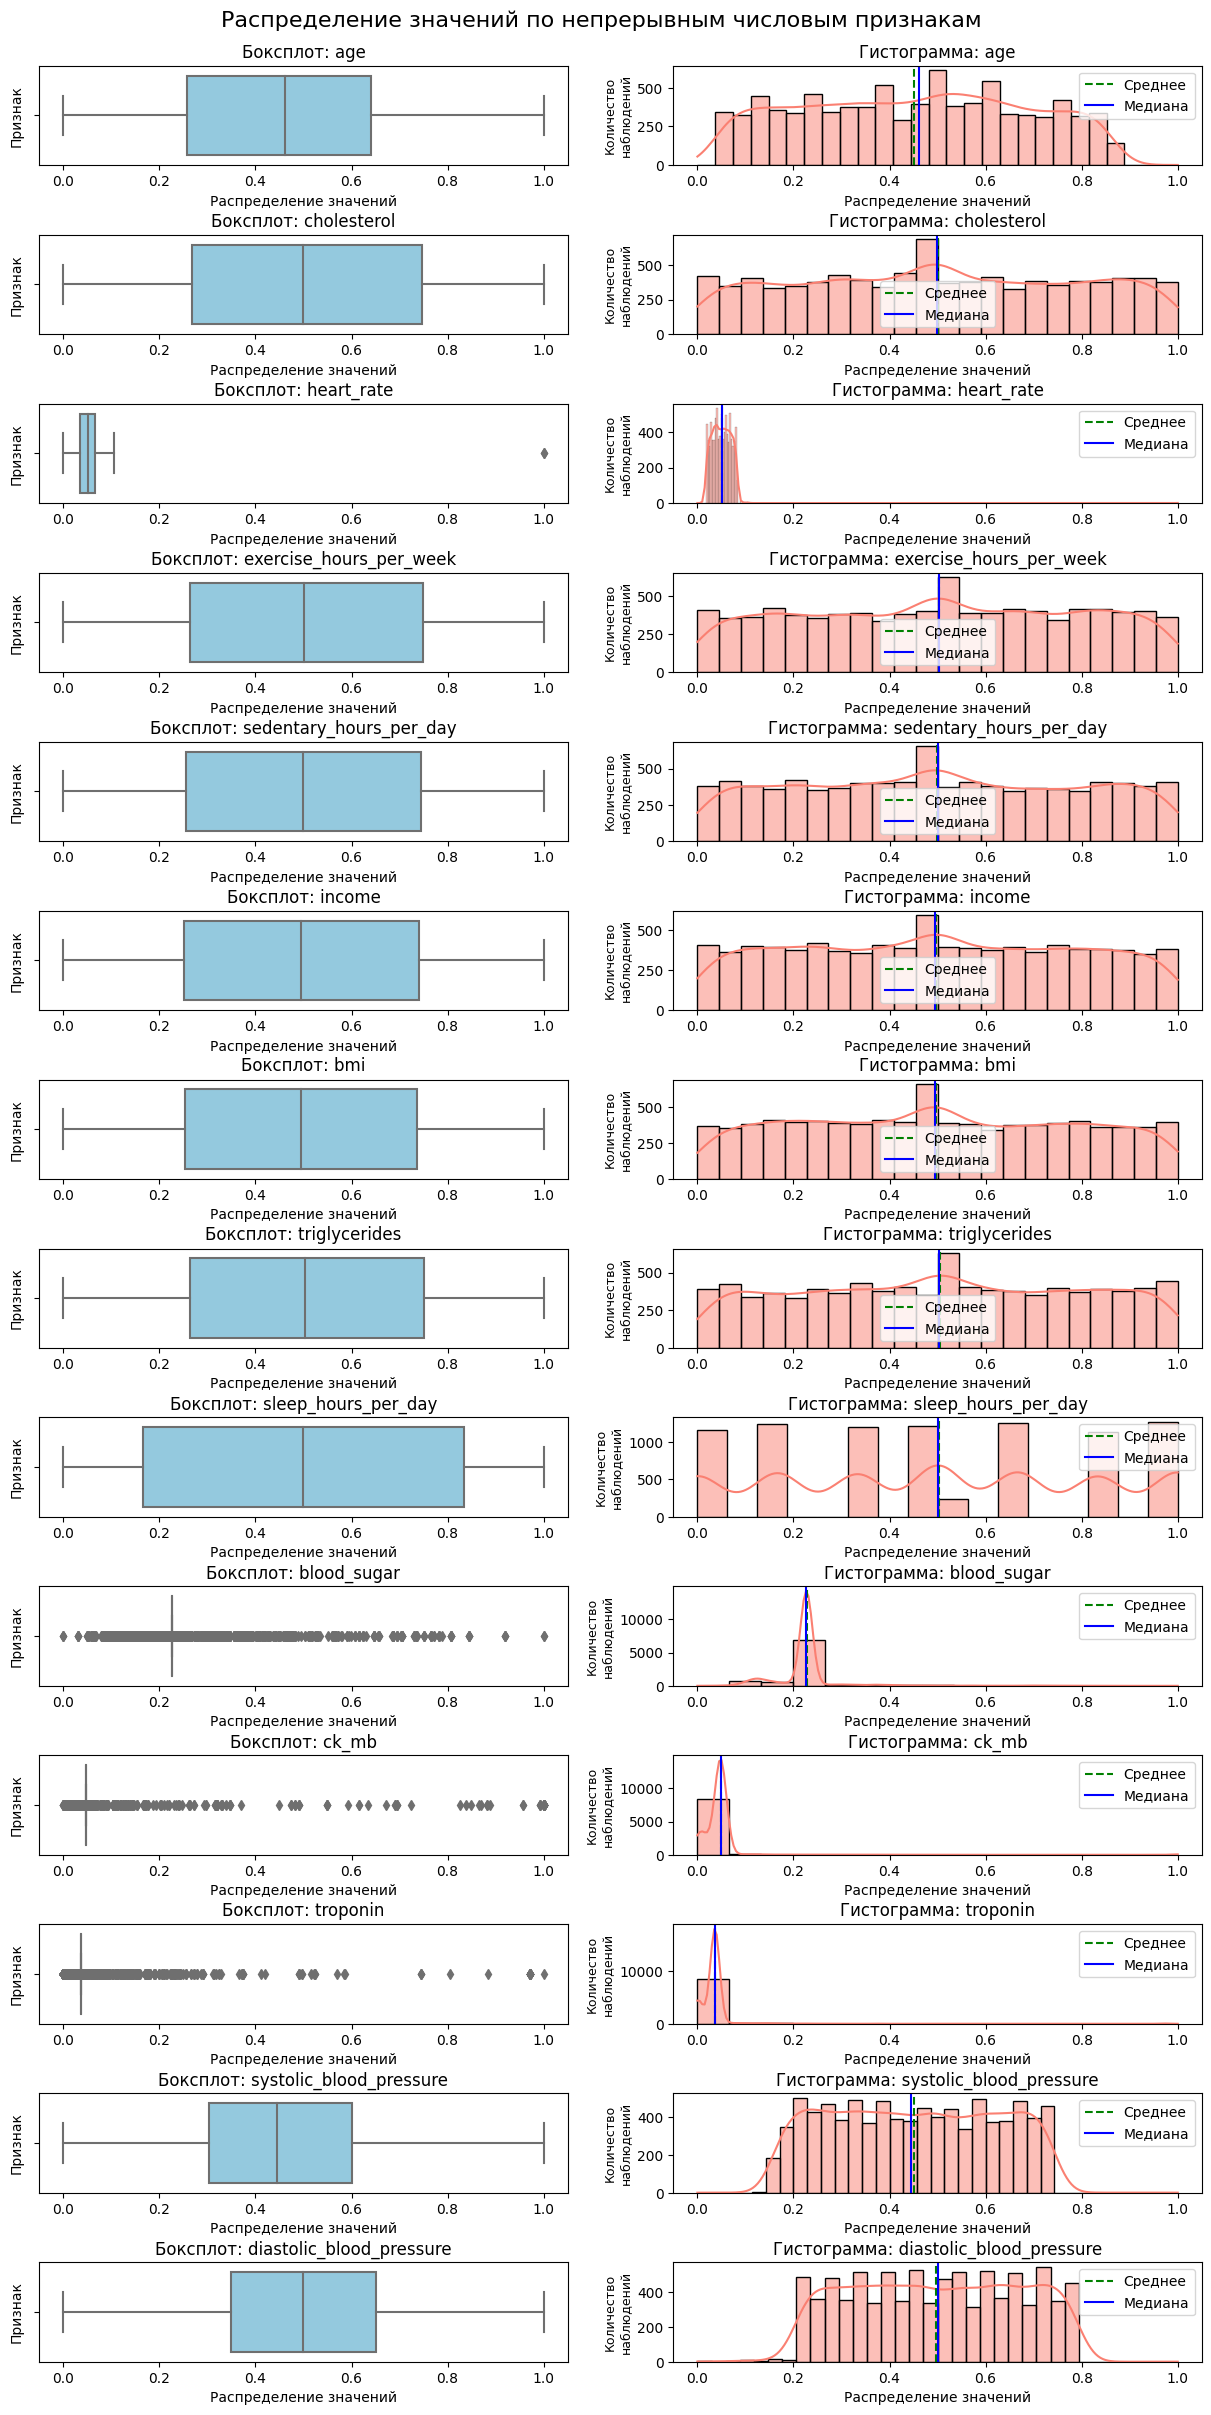

In [366]:
analyze_continuous_features(train, continuous_features=CONTINUOUS_FEATURES,
                                                        top=0.93)



- Большая часть значений - отмасштабирована.
- Можем увидеть аномалию в столбце `heart_rate` - надо устранить.  
- большое количество выбросов в столбцах `blood_sugar` `ck_mb` `troponin` - распространненная ситуация для медицинских данных, т. к. эти данные имеют широкие диапозоны значений, особенно у пациентов с сердечными проблемами, и "выбросы" здесь, скорее всего, не аномалии, а реальные показатели здоровья:  
    - Например, тропонин может сильно повышаться при инфаркте, и высокие значения — это не выбросы, а важные сигналы. Уровень сахара тоже варьируется в широком диапазоне.
    - При обучении моделей скорей всего потребуется использовать модели устойчивые к выюросам, или логарифмическое приобразование, чтобы нормализовать распределение, или же ввести новый бинарный признак с двумя знчениями - "высокое" и "низкое".  
- Наблюдение: sleep_hours_per_day распределен так, как буд то это дискретная категориальная величина, однако значения в этом столбце непрерывные. Возможно это ранее была дискретная величина, которую отмасштабировали.  


АНАЛИЗ ЧИСЛОВЫХ НЕПРЕРЫВНЫХ ПРИЗНАКОВ



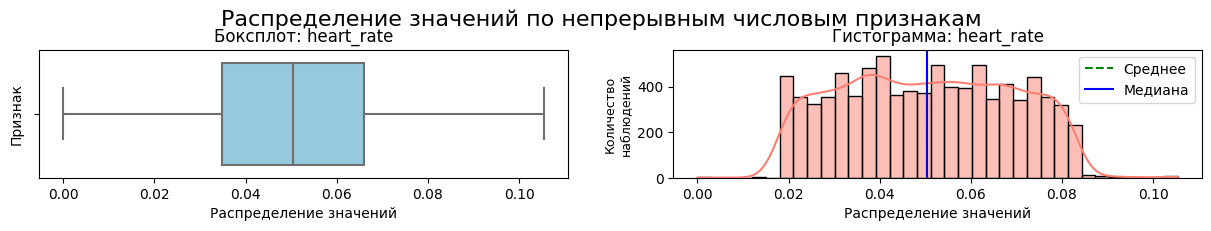

In [367]:
train = train.loc[train['heart_rate'] < 0.8]
analyze_continuous_features(train, continuous_features=['heart_rate'], top=0.75)

Успешно устранили аномалию в столбце `heart_rate`.  

Изинтереса давайте посмтроим графики связей `triglycerides` - триглициринов, которые связаны с накоплениями жира в организме и пульсом - `heart_rate`, немного ограничив диапозон последнего:

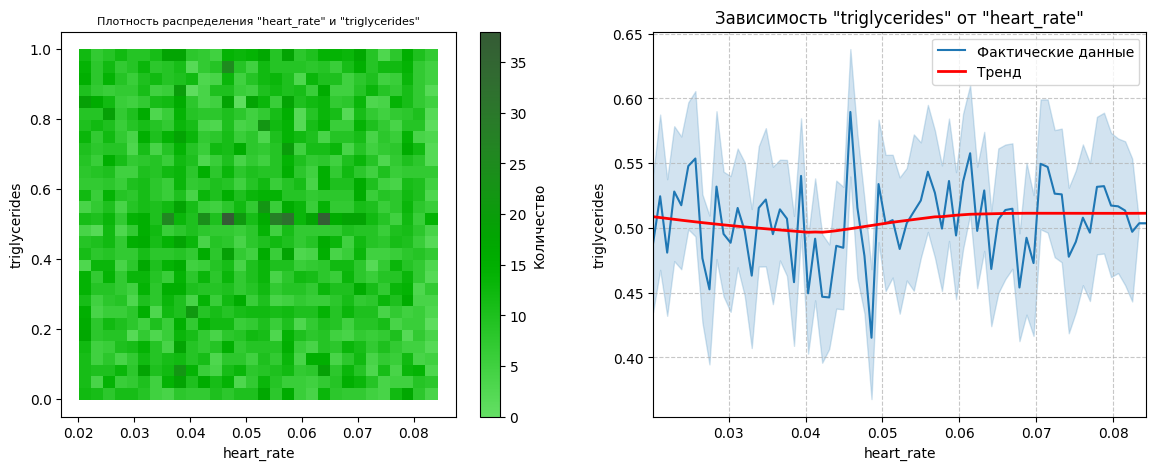

In [395]:
analyze_two_contonuous_features(train.loc[(train['heart_rate'] >= 0.02) & (train['heart_rate'] <= 0.085)], X='heart_rate', Y='triglycerides')

Можем увидеть, что в выборке есть небольшое скопление пациентов со средними значениями триглициринов и пульса. Так же можем увидеть, что у пацентов в выборке низкие и высокие значения пульса могут свидетельствовать о повышенном значении триглицерина.  
  
Проанализируем дискретные числовые признаки:


АНАЛИЗ ЧИСЛОВЫХ ДИСКРЕТНЫХ ПРИЗНАКОВ



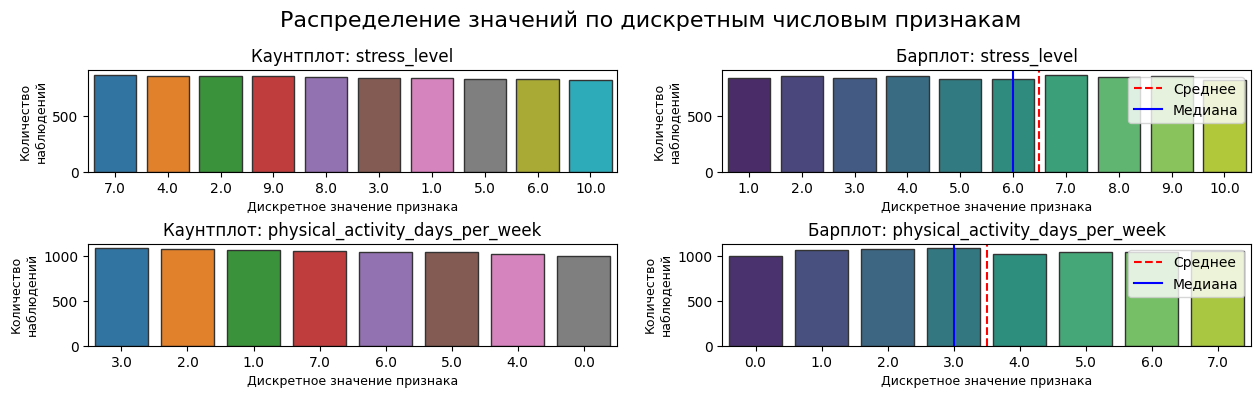

In [369]:
analyze_discrete_features(train, discrete_features=DISCRETE_FEATURES,
                          top=0.80)

Дискретные числовые признаки в датасете распределены весьма равномерно, можно заметить, что в основном паценты немного больше испытывают стресс и немнго меньше занимаются физическими активностями.  
  
Проанализируем категориальные признаки:


АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ



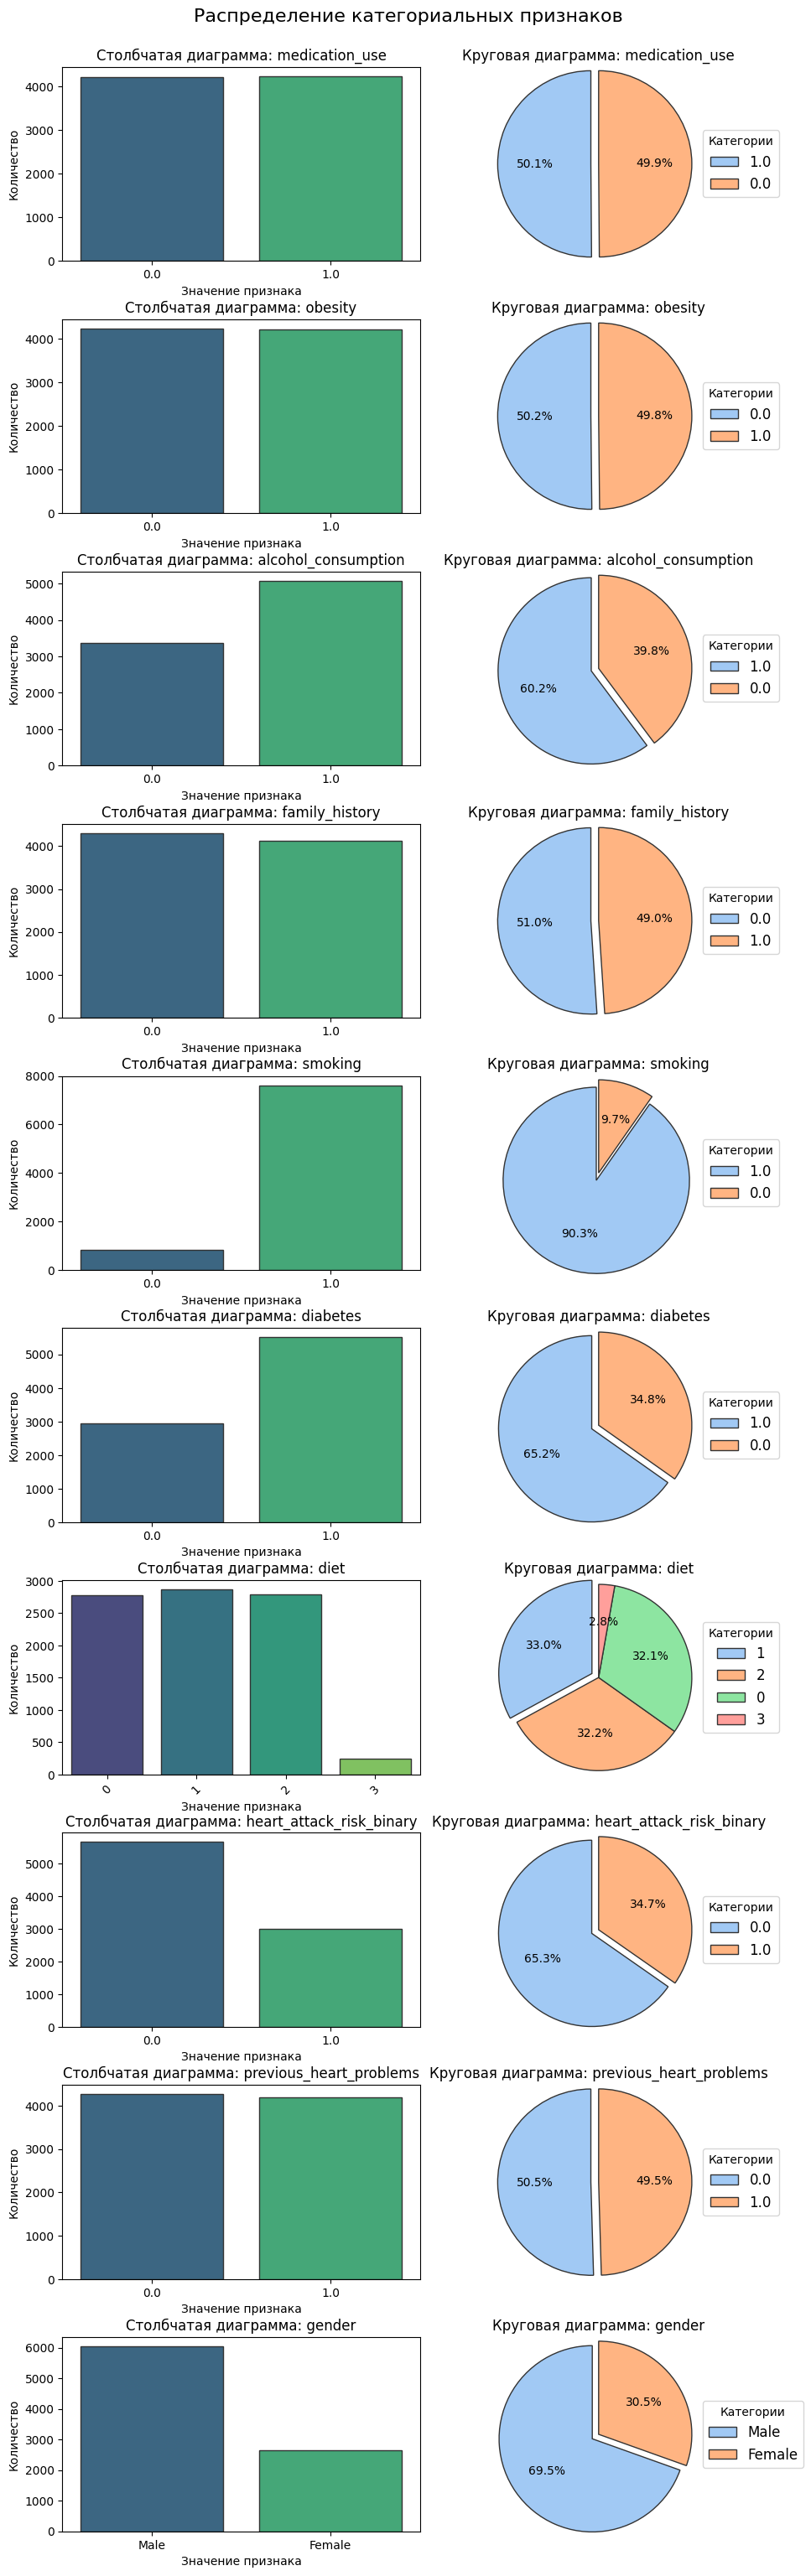

In [380]:
analyze_categorial_data(train, fig_size=(11, 35), top=0.95,
                        additional_features=CATEGORICAL_FEATURES)